# 20260608 — Corrected `g`-factor numerical experiment

Replaces the setup in `20260212_Get_g_factor`. See **`LITERATURE_AND_METHOD.md`** for the
physics and the full list of issues fixed here. In short, the old setup measured the
**coherent** far field of a **single finite slab** on a **Fibonacci grid mis-used as a tensor
grid**, which biases `g → +1`. Here we:

* use a **regular `(θ, φ)` grid** that matches how `FieldProjectionAngleMonitor` samples;
* add an **apodization window** to suppress lateral-edge diffraction;
* use a **plane wave + empty reference** (subtract the direct beam) instead of a TFSF box that
  cuts through the laterally-large slab;
* keep the slab **optically thin** and scan thickness (single-scattering check);
* set up a **realisation loop** so the diffuse intensity `I_d = ⟨|E|²⟩ − |⟨E⟩|²` can be formed
  in the analysis notebook.

**Nothing is uploaded unless `RUN = True`** (cloud runs bill your account).

In [14]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import sys, os
# Locate the AutomationModule package (project root) robustly across machines.
for cand in [r'../../../../', r'../../../../../tidy3d', r'H:\\phd stuff\\tidy3d']:
    p = os.path.abspath(cand)
    if os.path.isdir(os.path.join(p, 'AutomationModule')):
        sys.path.append(p); print('AutomationModule found at', p); break
from AutomationModule import *
import AutomationModule as AM
import g_tools as gt   # local corrected helpers

AutomationModule found at h:\Codes\tidy3d


In [16]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]
RUN = True   # <-- set True to upload + run on the Tidy3D cloud (this bills your account)

## Part 0 — validate the FDTD → near-to-far pipeline against analytic Mie

Before trusting the disorder runs, confirm that a single dielectric **sphere** reproduces the
analytic Mie `g` (`g_tools.mie_g`). A moderate index keeps it well resolved. TFSF is correct
here because the sphere is small and **fully enclosed** by the TFSF box.

In [ ]:
# # --- single-sphere Mie test ---
# lam0 = 5.0                       # um
# n_sphere, r_sphere = 2.0, 1.0    # moderate index -> clean, well-resolved Mie
# theta, phi = gt.regular_angle_grid(n_theta=181, n_phi=24)
# freq0 = td.C_0 / lam0

# buf = 3 * lam0
# Lcell = 2 * r_sphere + 2 * buf
# sphere = td.Structure(geometry=td.Sphere(center=(0, 0, 0), radius=r_sphere),
#                       medium=td.Medium(permittivity=n_sphere ** 2))
# src = td.TFSF(center=(0, 0, 0), size=(2 * r_sphere + lam0,) * 3,
#               source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
#               injection_axis=2, direction='+', name='tfsf')
# proj = td.FieldProjectionAngleMonitor(center=(0, 0, 0), size=(2 * r_sphere + 2 * lam0,) * 3,
#               name='proj', freqs=[freq0], phi=list(phi), theta=list(theta),
#               proj_distance=1e6, far_field_approx=True, window_size=(0, 0))
# sim_mie = td.Simulation(center=(0, 0, 0), size=(Lcell,) * 3,
#               grid_spec=td.GridSpec.auto(min_steps_per_wvl=20, wavelength=lam0),
#               sources=[src], monitors=[proj], run_time=2e-12,
#               boundary_spec=td.BoundarySpec.all_sides(td.PML()), structures=[sphere])
# print('Analytic Mie  g =', round(gt.mie_g(r_sphere, n_sphere, lam0), 4))
# sim_mie.plot(y=0); plt.show()

In [ ]:
# if RUN:
#     data = web.run(sim_mie, task_name='mie_validation', verbose=True)
#     pd = data['proj']
#     I = (np.abs(pd.Etheta.values) ** 2 + np.abs(pd.Ephi.values) ** 2).squeeze()  # (theta, phi)
#     g_fdtd = gt.asymmetry_parameter(theta, phi, I)
#     print(f'FDTD g = {float(g_fdtd):.4f}   |   Mie g = {gt.mie_g(r_sphere, n_sphere, lam0):.4f}')
#     # phase-function overlay
#     p_fdtd = gt.phase_function(theta, phi, I)
#     p_mie  = gt.mie_phase_function(theta, r_sphere, n_sphere, lam0)
#     plt.semilogy(np.degrees(theta), p_fdtd/np.max(p_fdtd), label='FDTD')
#     plt.semilogy(np.degrees(theta), p_mie/np.max(p_mie), '--', label='Mie')
#     plt.xlabel('theta (deg)'); plt.ylabel('phase function (norm.)'); plt.legend(); plt.show()
# else:
#     print('RUN is False — skipping the cloud Mie run.')

## Part 1 — thin-slab diffuse far field (the corrected `g` experiment)

Plane-wave illumination of an **optically thin** slab; record the far field with a regular
`(θ,φ)` grid and an apodization window. For **each structure** we also build an **empty
reference** (`structures=[]`) so the analysis can subtract the direct beam. Loop over a few
thicknesses (single-scattering plateau) and over realisations (for the coherent subtraction).

In [17]:
folder_path = r"../Structures"
project_name = "20260608_LSU_get_g_factor_v2"

Nfreq = 300
box_size = 14.3
thickness_um_list = [0.5, 1.0, 2.0]  # keep t << ls; check g is independent of t

min_steps_per_lambda = 18
absorbers = 80
runtime_ps = 20e-12

# regular product grid for the projection monitor (NOT a Fibonacci get_sphere!)
theta, phi = gt.regular_angle_grid(n_theta=181, n_phi=72)
print('angular grid:', theta.size, 'theta x', phi.size, 'phi')

angular grid: 181 theta x 72 phi


First maximum at x = 2.562629142772549, y = 0.021305211552347107


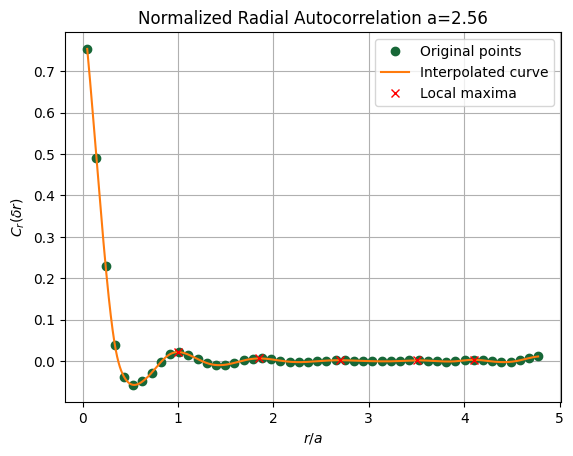

Configured successfully.


18:45:01 W. Europe Daylight Time WARNING: Structure at 'structures[0]' has      
                                 bounds that extend exactly to simulation edges.
                                 This can cause unexpected behavior. If         
                                 intending to extend the structure to infinity  
                                 along one dimension, use td.inf as a size      
                                 variable instead to make this explicit.        

                                 WARNING: Suppressed 3 WARNING messages.        


=== n_2.90_ff_0.2237.h5  t=0.5 um  cut=0.0350 ===
cells ~ 58.4 M   time steps ~ 187650


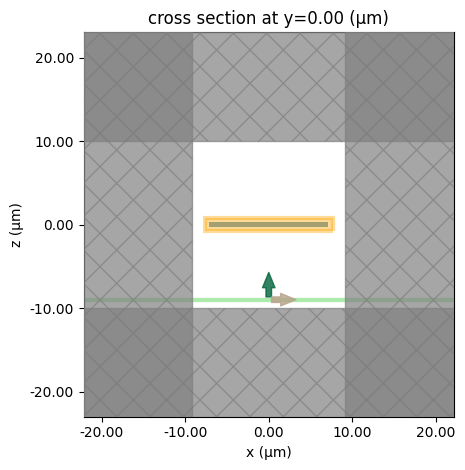

18:45:03 W. Europe Daylight Time Created task 'LSU_n_2.90_ff_0.2237_t0.5_0' with
                                 task_id                                        
                                 'fdve-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=161892;https://tidy3d.simulation.cloud/workbench?taskId=fdve-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=92864;https://tidy3d.simulation.cloud/workbench?taskId=fdve-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf\task]8;;\
                                 ]8;id=92864;https://tidy3d.simulation.cloud/workbench?taskId=fdve-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf\Id]8;;\]8;id=161892;https://tidy3d.simulation.cloud/workbench?taskId=fdve-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf\=]8;;\]8;id=18886;https://tidy3d.simulation.cloud/workbench?taskId=fdve-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf\fdve]8;;\]8;id=161892;https://tidy3d.simulation.cloud/workbench?taskId=fdve-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf\-de3c8f59-2e9c-4c4a-8069-1e6e6ddae8cf']8;;\.

                                 Task folder: ]8;id=725502;https://tidy3d.simulation.cloud/folders/folder-d970e14d-0b5d-42f8-89b5-96f671114b05\'20260608_LSU_get_g_factor_v2']8;;\.

Output()

18:45:12 W. Europe Daylight Time Maximum FlexCredit cost: 0.542. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

...

18:50:45 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=882595;https://tidy3d.simulation.cloud/workbench?taskId=fdve-71655113-0fc2-4472-abb4-5579dd3a850d\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=985190;https://tidy3d.simulation.cloud/workbench?taskId=fdve-71655113-0fc2-4472-abb4-5579dd3a850d\task]8;;\
                                 ]8;id=985190;https://tidy3d.simulation.cloud/workbench?taskId=fdve-71655113-0fc2-4472-abb4-5579dd3a850d\Id]8;;\]8;id=882595;https://tidy3d.simulation.cloud/workbench?taskId=fdve-71655113-0fc2-4472-abb4-5579dd3a850d\=]8;;\]8;id=138378;https://tidy3d.simulation.cloud/workbench?taskId=fdve-71655113-0fc2-4472-abb4-5579dd3a850d\fdve]8;;\]8;id=882595;https://tidy3d.simulation.cloud/workbench?taskId=fdve-71655113-0fc2-4472-abb4-5579dd3a850d\-71655113-0fc2-4472-abb4-5579dd3a850d']8;;\.

Configured successfully.


18:50:47 W. Europe Daylight Time WARNING: Structure at 'structures[0]' has      
                                 bounds that extend exactly to simulation edges.
                                 This can cause unexpected behavior. If         
                                 intending to extend the structure to infinity  
                                 along one dimension, use td.inf as a size      
                                 variable instead to make this explicit.        

                                 WARNING: Suppressed 3 WARNING messages.        


=== n_2.90_ff_0.2237.h5  t=1.0 um  cut=0.0699 ===
cells ~ 59.4 M   time steps ~ 187650


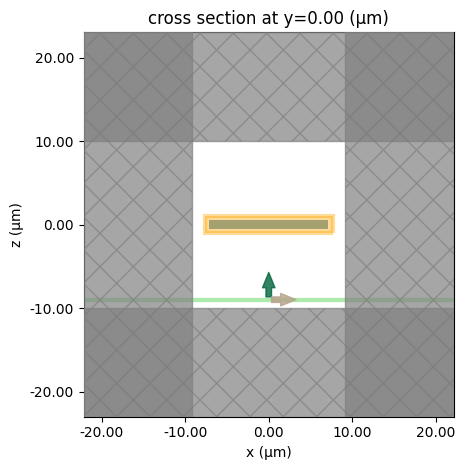

18:50:48 W. Europe Daylight Time Created task 'LSU_n_2.90_ff_0.2237_t1.0_0' with
                                 task_id                                        
                                 'fdve-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=543451;https://tidy3d.simulation.cloud/workbench?taskId=fdve-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=128414;https://tidy3d.simulation.cloud/workbench?taskId=fdve-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a\task]8;;\
                                 ]8;id=128414;https://tidy3d.simulation.cloud/workbench?taskId=fdve-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a\Id]8;;\]8;id=543451;https://tidy3d.simulation.cloud/workbench?taskId=fdve-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a\=]8;;\]8;id=687559;https://tidy3d.simulation.cloud/workbench?taskId=fdve-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a\fdve]8;;\]8;id=543451;https://tidy3d.simulation.cloud/workbench?taskId=fdve-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a\-320d9e64-e4d5-48b7-9d9d-9d98f5f9374a']8;;\.

                                 Task folder: ]8;id=419818;https://tidy3d.simulation.cloud/folders/folder-d970e14d-0b5d-42f8-89b5-96f671114b05\'20260608_LSU_get_g_factor_v2']8;;\.

Output()

18:50:50 W. Europe Daylight Time Maximum FlexCredit cost: 0.546. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

...

18:55:07 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=794769;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c263f317-71d5-4c58-933f-25d997826648\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=3039;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c263f317-71d5-4c58-933f-25d997826648\task]8;;\
                                 ]8;id=3039;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c263f317-71d5-4c58-933f-25d997826648\Id]8;;\]8;id=794769;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c263f317-71d5-4c58-933f-25d997826648\=]8;;\]8;id=253185;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c263f317-71d5-4c58-933f-25d997826648\fdve]8;;\]8;id=794769;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c263f317-71d5-4c58-933f-25d997826648\-c263f317-71d5-4c58-933f-25d997826648']8;;\.

Configured successfully.


18:55:09 W. Europe Daylight Time WARNING: Structure at 'structures[0]' has      
                                 bounds that extend exactly to simulation edges.
                                 This can cause unexpected behavior. If         
                                 intending to extend the structure to infinity  
                                 along one dimension, use td.inf as a size      
                                 variable instead to make this explicit.        

                                 WARNING: Suppressed 3 WARNING messages.        


=== n_2.90_ff_0.2237.h5  t=2.0 um  cut=0.1399 ===
cells ~ 61.8 M   time steps ~ 187650


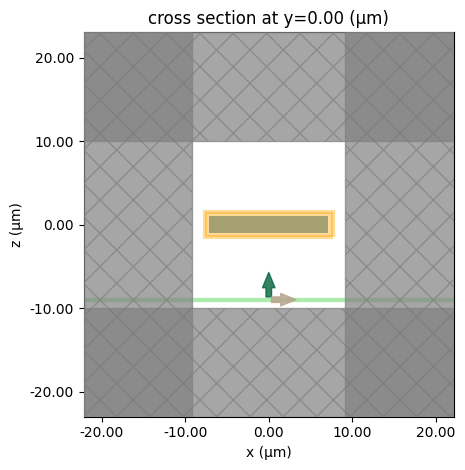

18:55:11 W. Europe Daylight Time Created task 'LSU_n_2.90_ff_0.2237_t2.0_0' with
                                 task_id                                        
                                 'fdve-f95f8d1e-fc7a-4c90-8a46-b7401521f1db' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=488998;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f95f8d1e-fc7a-4c90-8a46-b7401521f1db\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=768581;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f95f8d1e-fc7a-4c90-8a46-b7401521f1db\task]8;;\
                                 ]8;id=768581;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f95f8d1e-fc7a-4c90-8a46-b7401521f1db\Id]8;;\]8;id=488998;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f95f8d1e-fc7a-4c90-8a46-b7401521f1db\=]8;;\]8;id=351838;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f95f8d1e-fc7a-4c90-8a46-b7401521f1db\fdve]8;;\]8;id=488998;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f95f8d1e-fc7a-4c90-8a46-b7401521f1db\-f95f8d1e-fc7a-4c90-8a46-b7401521f1db']8;;\.

                                 Task folder: ]8;id=357172;https://tidy3d.simulation.cloud/folders/folder-d970e14d-0b5d-42f8-89b5-96f671114b05\'20260608_LSU_get_g_factor_v2']8;;\.

Output()

18:55:13 W. Europe Daylight Time Maximum FlexCredit cost: 0.559. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

...

Output()

18:59:46 W. Europe Daylight Time status = postprocess

Output()

18:59:57 W. Europe Daylight Time status = success

18:59:59 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=373526;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8026a64a-d50a-4f77-9432-8408976c0f42\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=590981;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8026a64a-d50a-4f77-9432-8408976c0f42\task]8;;\
                                 ]8;id=590981;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8026a64a-d50a-4f77-9432-8408976c0f42\Id]8;;\]8;id=373526;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8026a64a-d50a-4f77-9432-8408976c0f42\=]8;;\]8;id=476897;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8026a64a-d50a-4f77-9432-8408976c0f42\fdve]8;;\]8;id=373526;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8026a64a-d50a-4f77-9432-8408976c0f42\-8026a64a-d50a-4f77-9432-8408976c0f42']8;;\.

In [18]:
# Pick which structures to run. Add more .h5 realisations to `realization_files`
# (same statistics, different seed) to enable a clean coherent/incoherent split.
target = dict(n=2.90, ff=0.2237)     # the structure validated in the analysis notebook

for dirpath, _, filenames in os.walk(folder_path):
    for filename in sorted(filenames):
        
        if not filename.endswith('.h5'):
            continue
        ff = float(re.search(r'ff_([+-]?\d+(?:\.\d+)?)', filename).group(1))
        n_value = float(re.search(r'n_([+-]?\d+(?:\.\d+)?)', filename).group(1))
        if not (abs(n_value - target['n']) < 1e-6 and abs(ff - target['ff']) < 1e-3):
            continue
        file = os.path.join(dirpath, filename)
        a_value, _, _ = AM.get_a_from_h5_eps(file, L=box_size, plot_correlation=True)
        a = float(a_value)
        lambdas = a/np.array([0.05, 1.7])   # a/lambda ~ 0.05 .. 1.7 for nu = 0.05 .. 1.7

        for t_um in thickness_um_list:
            cut = t_um / box_size
            s = AM.loadAndRunStructure(
                    key=tidy3dAPI, file_path=file, direction='z', lambda_range=lambdas,
                    box_size=box_size, runtime_ps=runtime_ps,
                    min_steps_per_lambda=min_steps_per_lambda, scaling=1,
                    shuoff_condtion=1e-20, verbose=True, monitors=[], cell_size_manual=20,
                    freqs=Nfreq, boundaries='absorbers', cut_condition=cut,
                    source='planewave', absorbers=absorbers, use_permittivity=False,
                    sim_name=f'{Path(filename).stem}_t{t_um}')

            # corrected far-field monitor: regular (theta, phi) grid, CLOSED box -> full 4*pi.
            # NOTE: window_size (apodization) is only valid for a single-surface projection
            # monitor, not a closed box, so it is omitted here; edge/truncation effects are
            # instead limited by the absorbers + the lateral buffer (size = slab + 1 um, sim =
            # slab + 4 um). For heavy apodization use separate +z/-z surface monitors.
            proj = td.FieldProjectionAngleMonitor(
                    center=(0, 0, 0),
                    size=(s.t_slab_x + 1, s.t_slab_y + 1, s.t_slab_z + 1),
                    name='field_monitor', freqs=s.monitor_freqs,
                    phi=list(phi), theta=list(theta),
                    proj_distance=1e6, far_field_approx=True)

            # Widen x,y to give the finite slab a lateral air buffer (keeps it off the
            # absorbers). KEEP the original z-size (s.Lz = cell_size_manual): the plane-wave
            # source sits near the -z edge of that domain, and z must hold several wavelengths
            # (lambda up to 10 um). Shrinking z would put the source outside the domain.
            # Keep the structure's AUTO grid (fine only near the slab, coarse in the air buffer):
            # a uniform fine grid over the whole 18x18x20 um box would be ~75 M cells. For a
            # strict uniform-grid check, add 'grid_spec': td.GridSpec.uniform(s.dl) below.
            sim = s.sim.copy(update={
                    'size': (s.t_slab_x + 4, s.t_slab_y + 4, s.Lz),
                    'monitors': [proj]})
            sim0 = sim.copy(update={'structures': []})   # empty reference (incident only)

            print(f'\n=== {filename}  t={t_um} um  cut={cut:.4f} ===')
            print(f'cells ~ {sim.num_cells*1e-6:.1f} M   time steps ~ {sim.num_time_steps}')
            sim.plot(y=0); plt.show()

            folder_desc = rf'../../../../data/{project_name}/n_{n_value:.2f}'
            os.makedirs(folder_desc, exist_ok=True)
            sim_name = f'LSU_{Path(filename).stem}_t{t_um}'
            txt = os.path.join(folder_desc, sim_name + '.txt')

            if RUN:
                if os.path.exists(txt):
                    print('Exists — skipping.'); continue
                id0 = web.upload(sim0, folder_name=project_name, task_name=sim_name + '_0', verbose=True)
                ids = web.upload(sim,  folder_name=project_name, task_name=sim_name,        verbose=True)
                with open(txt, 'w') as fh:
                    fh.write(id0 + '\n' + ids)   # line0 = reference, line1 = structure
                web.start(id0); web.start(ids); web.monitor(ids)
            else:
                print('RUN is False — built locally only (no upload). '
                      'Set RUN=True to submit, or call web.estimate_cost after an upload to preview cost.')

### Notes / convergence
* **Thickness scan** — `g` from the analysis must be independent of `t` for `t ≪ ℓs`. If it
  drifts with `t`, multiple scattering is contaminating the phase function; reduce `t`.
* **Realisations** — a clean coherent subtraction needs several independent structures with the
  same statistics. Add their `.h5` files under `../Structures` (or a subfolder) so the loop
  picks them up; the analysis stacks them along the realisation axis.
* **Resolution / runtime / angular grid** — rerun with larger `min_steps_per_lambda`, longer
  `runtime_ps`, and finer `(n_theta, n_phi)` until `g` stops moving.
* The **reference** (`_0`) run is the incident beam only; the analysis subtracts its projected
  field from the structure run to isolate the scattered field.